In [4]:
import sys
import os

# Détection automatique de la racine du projet
# On remonte d'un niveau depuis le dossier 'notebooks'
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Ajout au path pour pouvoir faire "from src..."
if project_root not in sys.path:
    sys.path.append(project_root)

# Définition des chemins absolus
DATA_RAW = os.path.join(project_root, "data", "raw")
DATA_PROCESSED = os.path.join(project_root, "data", "processed")
GEO_PATH = os.path.join(project_root, "geo")

print(f"Système configuré. Racine : {project_root}")

Système configuré. Racine : c:\Users\valen\OneDrive\Documents\GitHub\Projet-de-Statapp---WFP-


# Fonctions

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def analyze_optimal_lag(df, state_name, target_var='inadequate', climate_var='WSI', max_lag=6):
    """
    Computes the optimal time lag between a climate variable and food insecurity,
    then displays the correlation results and the corresponding dual-axis plot.
    """
    # 1. Data preparation for the specific state
    # Handles both potential column names for administrative boundaries
    col_state = 'NAME_1' if 'NAME_1' in df.columns else 'ADM1_NAME'
    df_state = df[df[col_state] == state_name].sort_values('time').copy()
    
    if df_state.empty:
        print(f"Error: No data found for state: {state_name}")
        return None

    print(f"--- LAG ANALYSIS: {climate_var} vs {target_var} ({state_name}) ---")
    
    # 2. Iterating through lags to compute Pearson correlations
    lags = list(range(max_lag + 1))
    corrs = []
    
    for lag in lags:
        # Dynamic column selection: uses the raw variable for lag 0, otherwise looks for the lag column
        col_name = climate_var if lag == 0 else f'{climate_var}_Lag_{lag}'
        
        if col_name in df_state.columns:
            # Drop NaN values to ensure a clean correlation calculation
            valid_data = df_state[[target_var, col_name]].dropna()
            if len(valid_data) > 2:
                correlation = valid_data[target_var].corr(valid_data[col_name])
                corrs.append(correlation)
                print(f"  Lag {lag} month(s): Correlation = {correlation:.3f}")
            else:
                corrs.append(0)
        else:
            corrs.append(0)
            
    # 3. Identify the best Lag based on the highest absolute correlation value
    best_idx = np.argmax([abs(c) for c in corrs])
    best_lag = lags[best_idx]
    best_corr = corrs[best_idx]
    
    print(f"\nRESULT: Optimal delay is {best_lag} month(s) (Corr: {best_corr:.3f})")

    # 4. Visualization logic
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Left Axis: Food Insecurity (Target)
    color_target = 'tab:red'
    ax1.set_xlabel('Date')
    ax1.set_ylabel(f"{target_var} (%)", color=color_target, fontweight='bold')
    ax1.plot(df_state['time'], df_state[target_var], color=color_target, linewidth=2, label=f'{target_var} (Actual)')
    ax1.tick_params(axis='y', labelcolor=color_target)
    ax1.grid(alpha=0.3)

    # Right Axis: Climate Variable at the optimal lag
    ax2 = ax1.twinx()
    color_climate = 'tab:blue'
    best_col_name = climate_var if best_lag == 0 else f'{climate_var}_Lag_{best_lag}'
    
    ax2.set_ylabel(f"{climate_var} (Lag {best_lag})", color=color_climate, fontweight='bold')
    ax2.fill_between(df_state['time'], df_state[best_col_name], color=color_climate, alpha=0.2, label=f"{climate_var} (t-{best_lag})")
    ax2.tick_params(axis='y', labelcolor=color_climate)
    
    plt.title(f"Impact of {climate_var} on {target_var} in {state_name} (Best Lag: {best_lag} months)", fontsize=14)
    
    # Merge legends from both axes into a single box
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True)
    
    plt.tight_layout()
    plt.show()
    
    return {"state": state_name, "best_lag": best_lag, "correlation": best_corr}

In [5]:
filepath = '../data/processed/NIGERIA_WFP_ENGINEERED.csv'
df = pd.read_csv(filepath)

#  Official geopolitical mapping
zones = {
    'North': ['Borno', 'Kano', 'Kaduna', 'Katsina', 'Sokoto', 'Kebbi', 'Zamfara', 'Jigawa', 'Yobe', 'Adamawa', 'Bauchi', 'Gombe', 'Taraba', 'Niger', 'Plateau', 'Nasarawa', 'Benue', 'Kogi', 'Kwara', 'Federal Capital Territory'],
    'South': ['Lagos', 'Ogun', 'Oyo', 'Osun', 'Ekiti', 'Ondo', 'Abia', 'Anambra', 'Ebonyi', 'Enugu', 'Imo', 'Akwa Ibom', 'Bayelsa', 'Cross River', 'Delta', 'Edo', 'Rivers']
}

# Mapping function for your DataFrame
df['geopolitical_region'] = df['NAME_1'].apply(lambda x: 'North' if x in zones['North'] else 'South')

# North and South separation

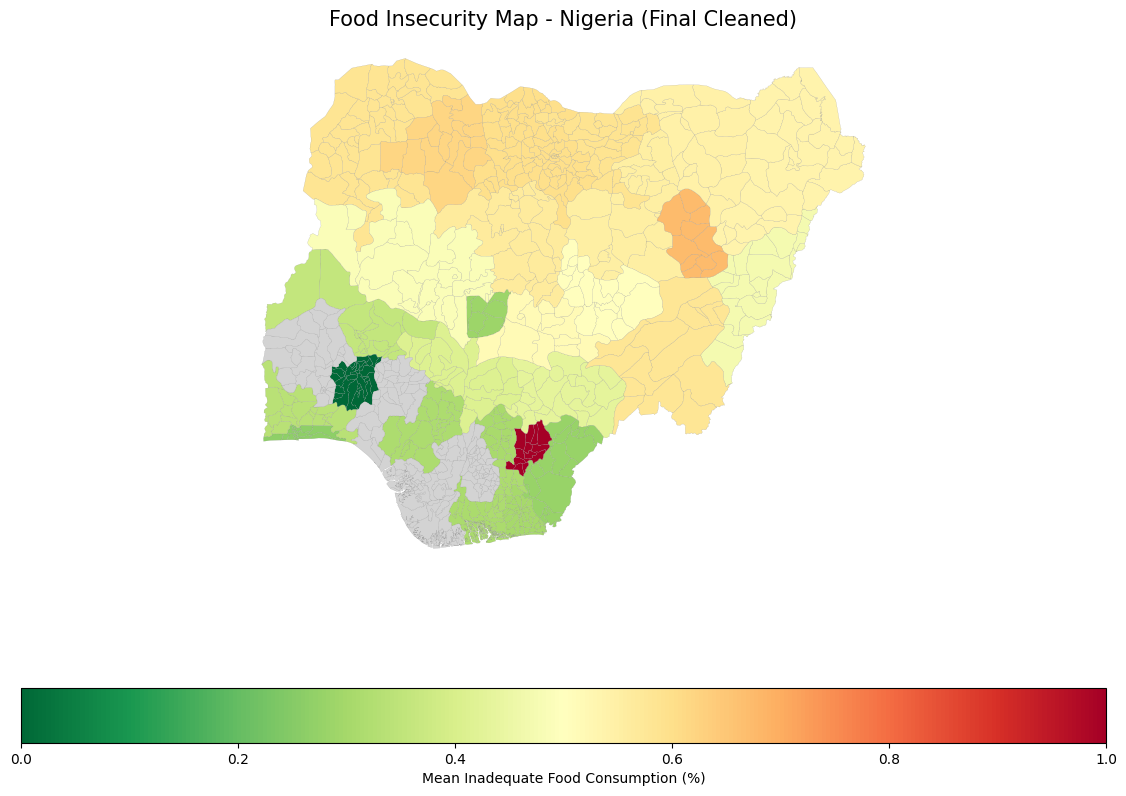

States still in grey: ['Anambra' 'Bayelsa' 'Delta' 'Ekiti' 'Imo' 'Ondo' 'Oyo']


In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Load the geographical shapes
geo_path = '../geo/gadm41_NGA_2.json' 
gdf = gpd.read_file(geo_path)

# 2. STRATEGY: Remove all spaces and special characters from BOTH datasets
# This is the safest way to ensure a match
def clean_names(name):
    return str(name).replace(' ', '').replace('-', '').replace('_', '')

# Clean the GeoJSON names
gdf['NAME_1_clean'] = gdf['NAME_1'].apply(clean_names)

# Clean the DataFrame names and handle the 'Abuja' exception
df['NAME_1'] = df['NAME_1'].replace({'Abuja': 'Federal Capital Territory'})
df['NAME_1_clean'] = df['NAME_1'].apply(clean_names)

# 3. Re-calculate stats with cleaned names
state_stats = df.groupby('NAME_1_clean')['inadequate'].mean().reset_index()

# 4. Merge using the cleaned columns
merged = gdf.merge(state_stats, on='NAME_1_clean', how='left')

# 5. Plotting
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

merged.plot(column='inadequate', 
            cmap='RdYlGn_r', 
            linewidth=0.1, # Thin lines because it's Admin 2
            ax=ax, 
            edgecolor='0.5', 
            missing_kwds={'color': 'lightgrey', 'label': 'No survey data'}, 
            legend=True,
            legend_kwds={'label': "Mean Inadequate Food Consumption (%)", 'orientation': "horizontal"})

ax.set_title('Food Insecurity Map - Nigeria (Final Cleaned)', fontsize=15)
ax.axis('off')
plt.show()

# 6. Check if holes remain (other than the 7 states without data)
missing_after = merged[merged['inadequate'].isna()]['NAME_1'].unique()
print("States still in grey:", missing_after)

In [9]:
# Check which states from the map have no data associated
missing_states = merged[merged['inadequate'].isna()]['NAME_1'].unique()

if len(missing_states) > 0:
    print(f"States with no data (White holes): {missing_states}")
else:
    print("No missing data for the states present in the GeoJSON.")

States with no data (White holes): ['AkwaIbom' 'Anambra' 'Bayelsa' 'CrossRiver' 'Delta' 'Ekiti'
 'FederalCapitalTerritory' 'Imo' 'Nasarawa' 'Ondo' 'Oyo']


In [10]:
# List names in your stats vs names in the GeoJSON
print("Names in CSV stats:", sorted(df['NAME_1'].unique()))
print("\nNames in GeoJSON:", sorted(gdf['NAME_1'].unique()))

Names in CSV stats: ['Abia', 'Abuja', 'Adamawa', 'Akwa Ibom', 'Bauchi', 'Benue', 'Borno', 'Cross River', 'Ebonyi', 'Edo', 'Enugu', 'Gombe', 'Jigawa', 'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nassarawa', 'Niger', 'Ogun', 'Osun', 'Plateau', 'Rivers', 'Sokoto', 'Taraba', 'Yobe', 'Zamfara']

Names in GeoJSON: ['Abia', 'Adamawa', 'AkwaIbom', 'Anambra', 'Bauchi', 'Bayelsa', 'Benue', 'Borno', 'CrossRiver', 'Delta', 'Ebonyi', 'Edo', 'Ekiti', 'Enugu', 'FederalCapitalTerritory', 'Gombe', 'Imo', 'Jigawa', 'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nasarawa', 'Niger', 'Ogun', 'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers', 'Sokoto', 'Taraba', 'Yobe', 'Zamfara']


### Note on Data Coverage and Spatial Constraints

The geographical visualization of food insecurity across Nigeria reveals certain "data gaps," specifically in the following seven states: **Anambra, Bayelsa, Delta, Ekiti, Imo, Ondo, and Oyo**. 

These areas appear in grey on the map due to their absence in the original World Food Programme (WFP) datasets used for this study (`NIGERIA_WFP_ADMIN1.csv` and the processed versions). 

#### Methodological Explanation:
1. **Targeted Monitoring**: WFP's mobile Vulnerability Analysis and Mapping (mVAM) typically prioritizes regions with higher risks of acute food insecurity. Historically, this focuses on the **North-East** (due to conflict-related instability) and the **North-West/Sahelian belt** (due to high climatic vulnerability).
2. **Geographical Focus**: Most of the missing states are located in the **South** and **South-West** zones. While these regions face economic challenges, they are often characterized by different food system dynamics (market-driven) and were not covered by the high-frequency survey rounds available in this specific dataset.
3. **Implications for Analysis**: The absence of these states represents a **spatial coverage bias**. Consequently, the comparative analysis between "North" and "South" is conducted using the available representative states in the South (such as Lagos, Rivers, or Cross River), which still allow for a robust identification of diverging food security trends between the two macro-regions.

This limitation is documented as a constraint of the secondary data source and highlights the need for expanded sub-national monitoring in future research.

C:\Users\valen\AppData\Local\Temp\ipykernel_20792\4019988763.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


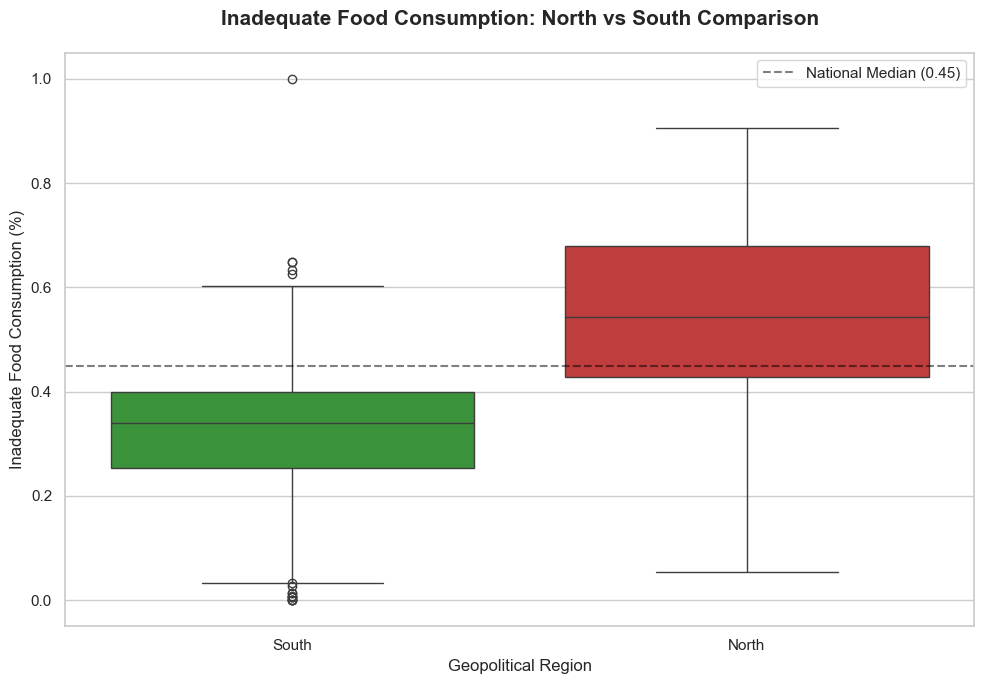

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuration of the visual theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

# 2. Creating the boxplot
# We use the 'geopolitical_region' column created earlier
# Comparing the distribution of the 'inadequate' variable
ax = sns.boxplot(
    data=df, 
    x='geopolitical_region', 
    y='inadequate', 
    palette={'North': 'tab:red', 'South': 'tab:green'},
    order=['South', 'North'] # Ordering for a clear left-to-right comparison
)

# 3. Adding titles and labels
plt.title('Inadequate Food Consumption: North vs South Comparison', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Geopolitical Region', fontsize=12)
plt.ylabel('Inadequate Food Consumption (%)', fontsize=12)

# 4. Adding a horizontal line for the national median (optional but useful)
national_median = df['inadequate'].median()
plt.axhline(national_median, color='black', linestyle='--', alpha=0.5, label=f'National Median ({national_median:.2f})')
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

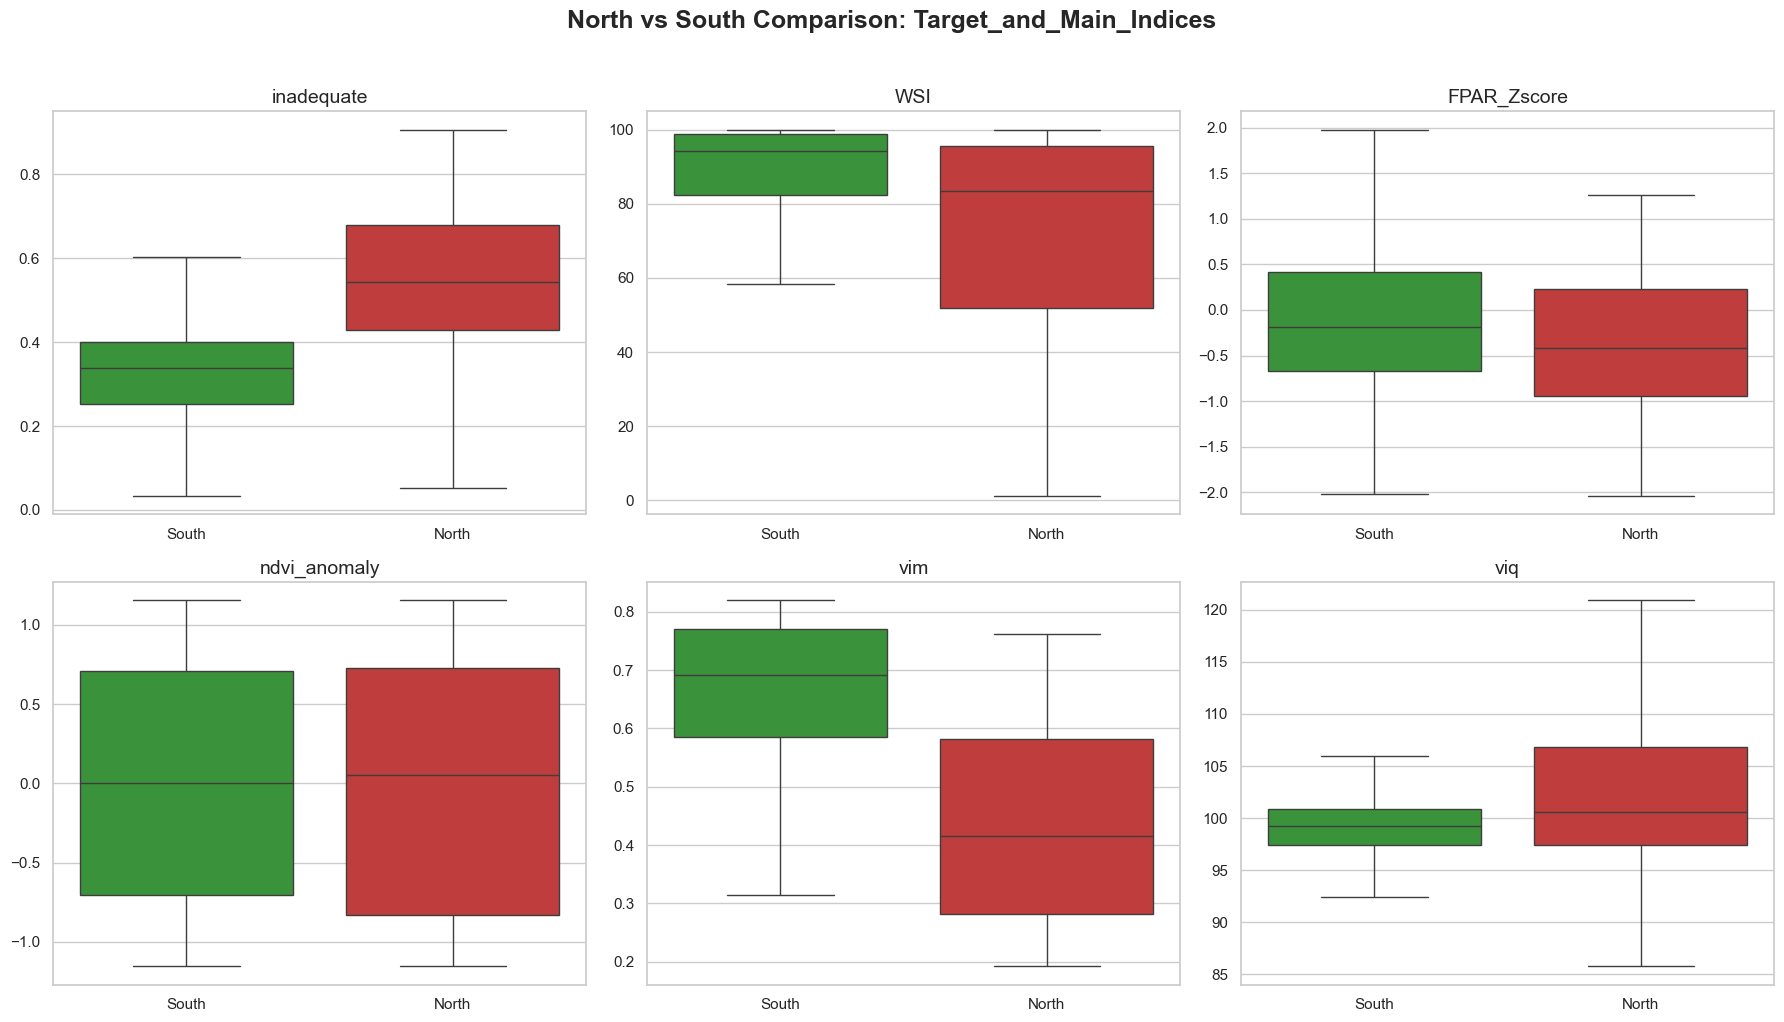

C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

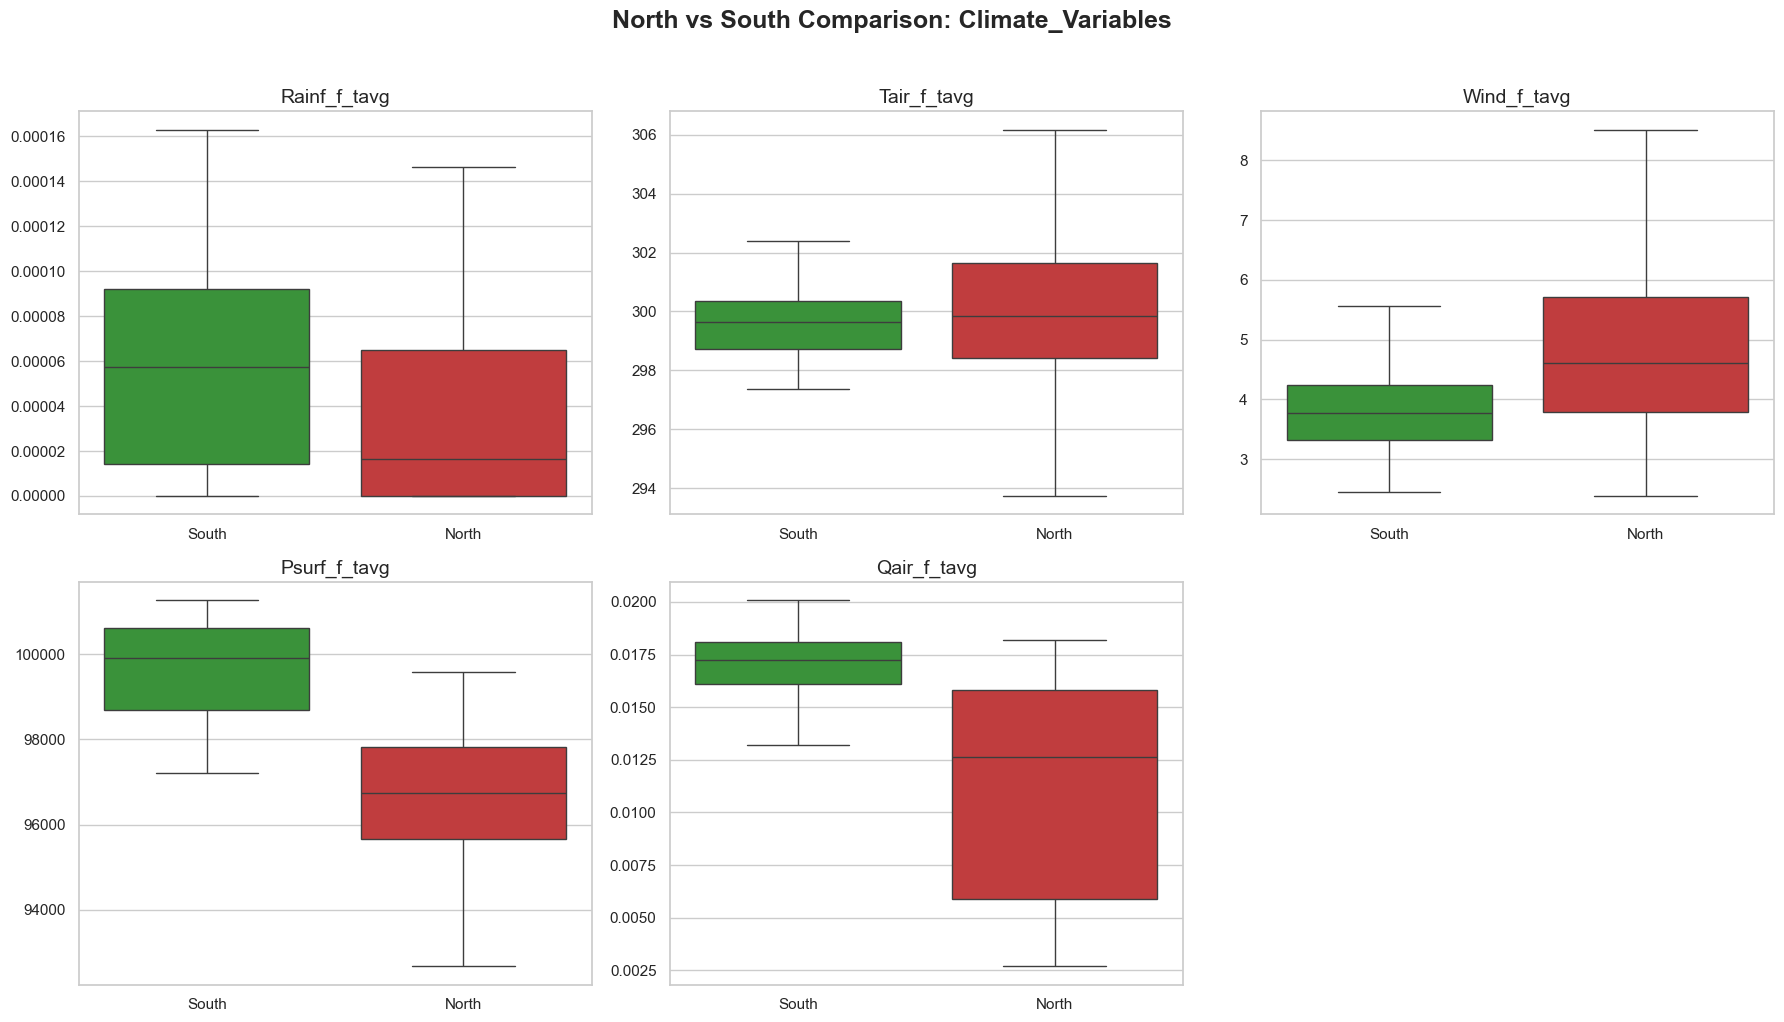

C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

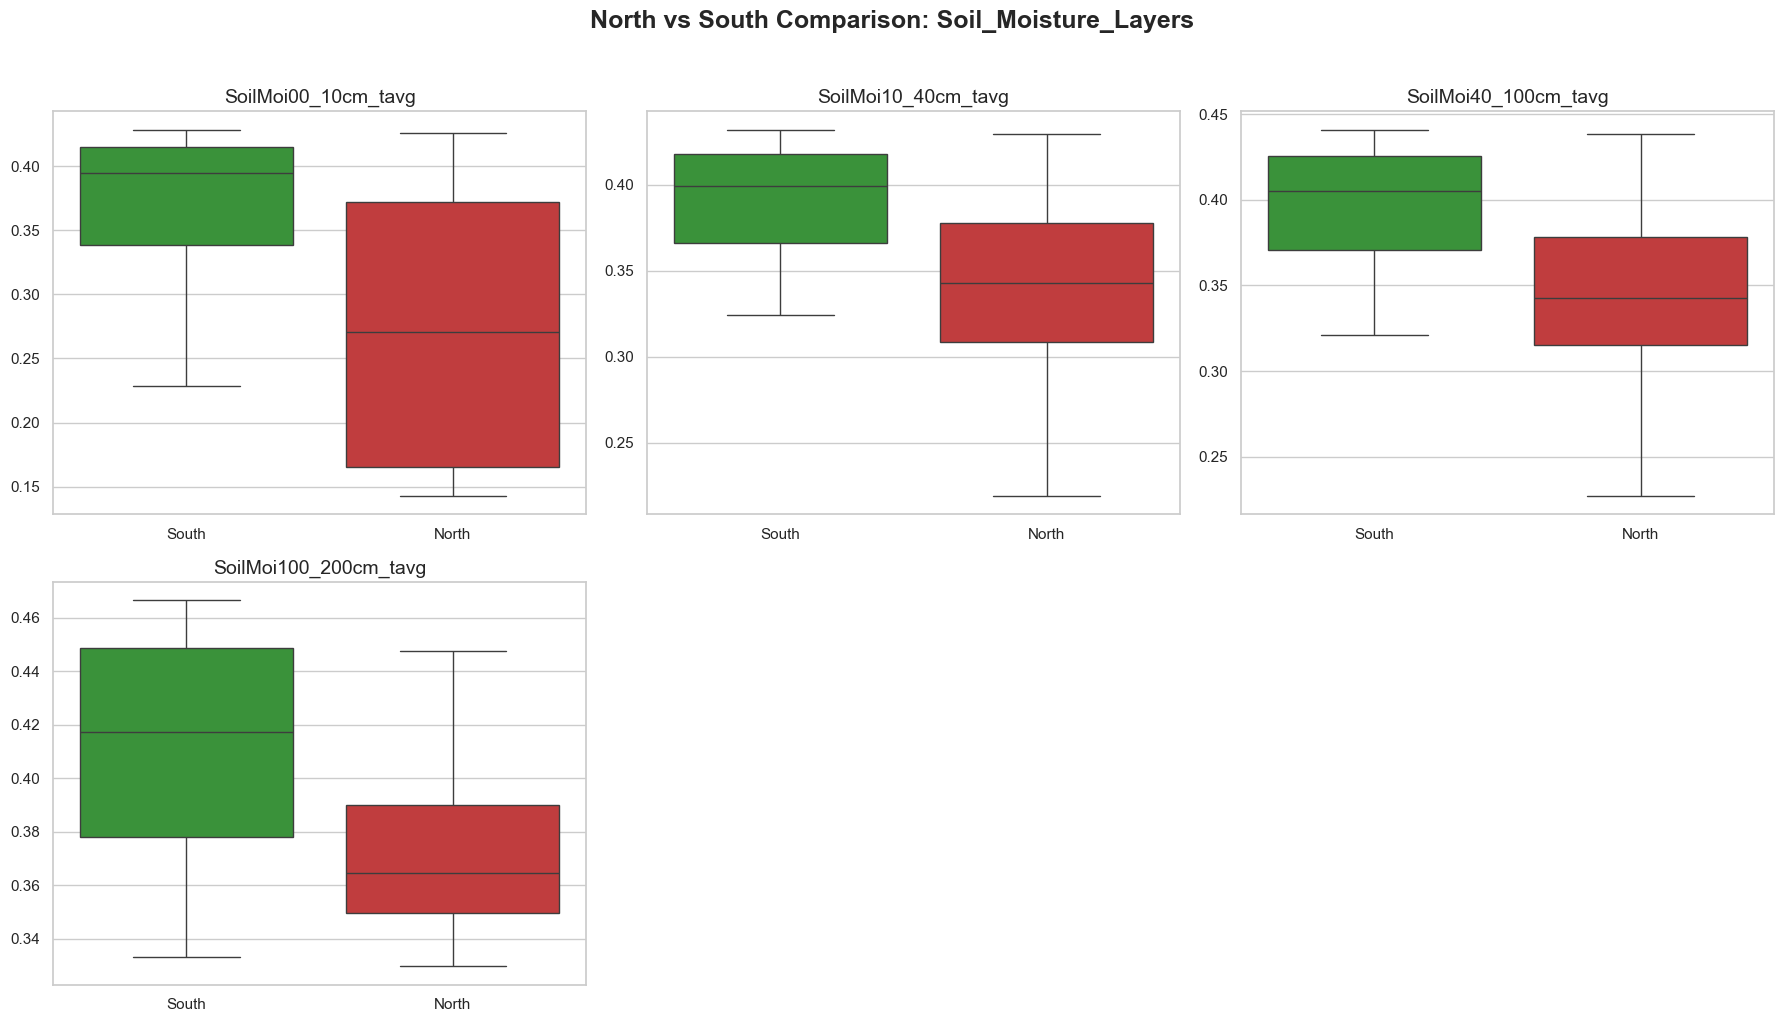

C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

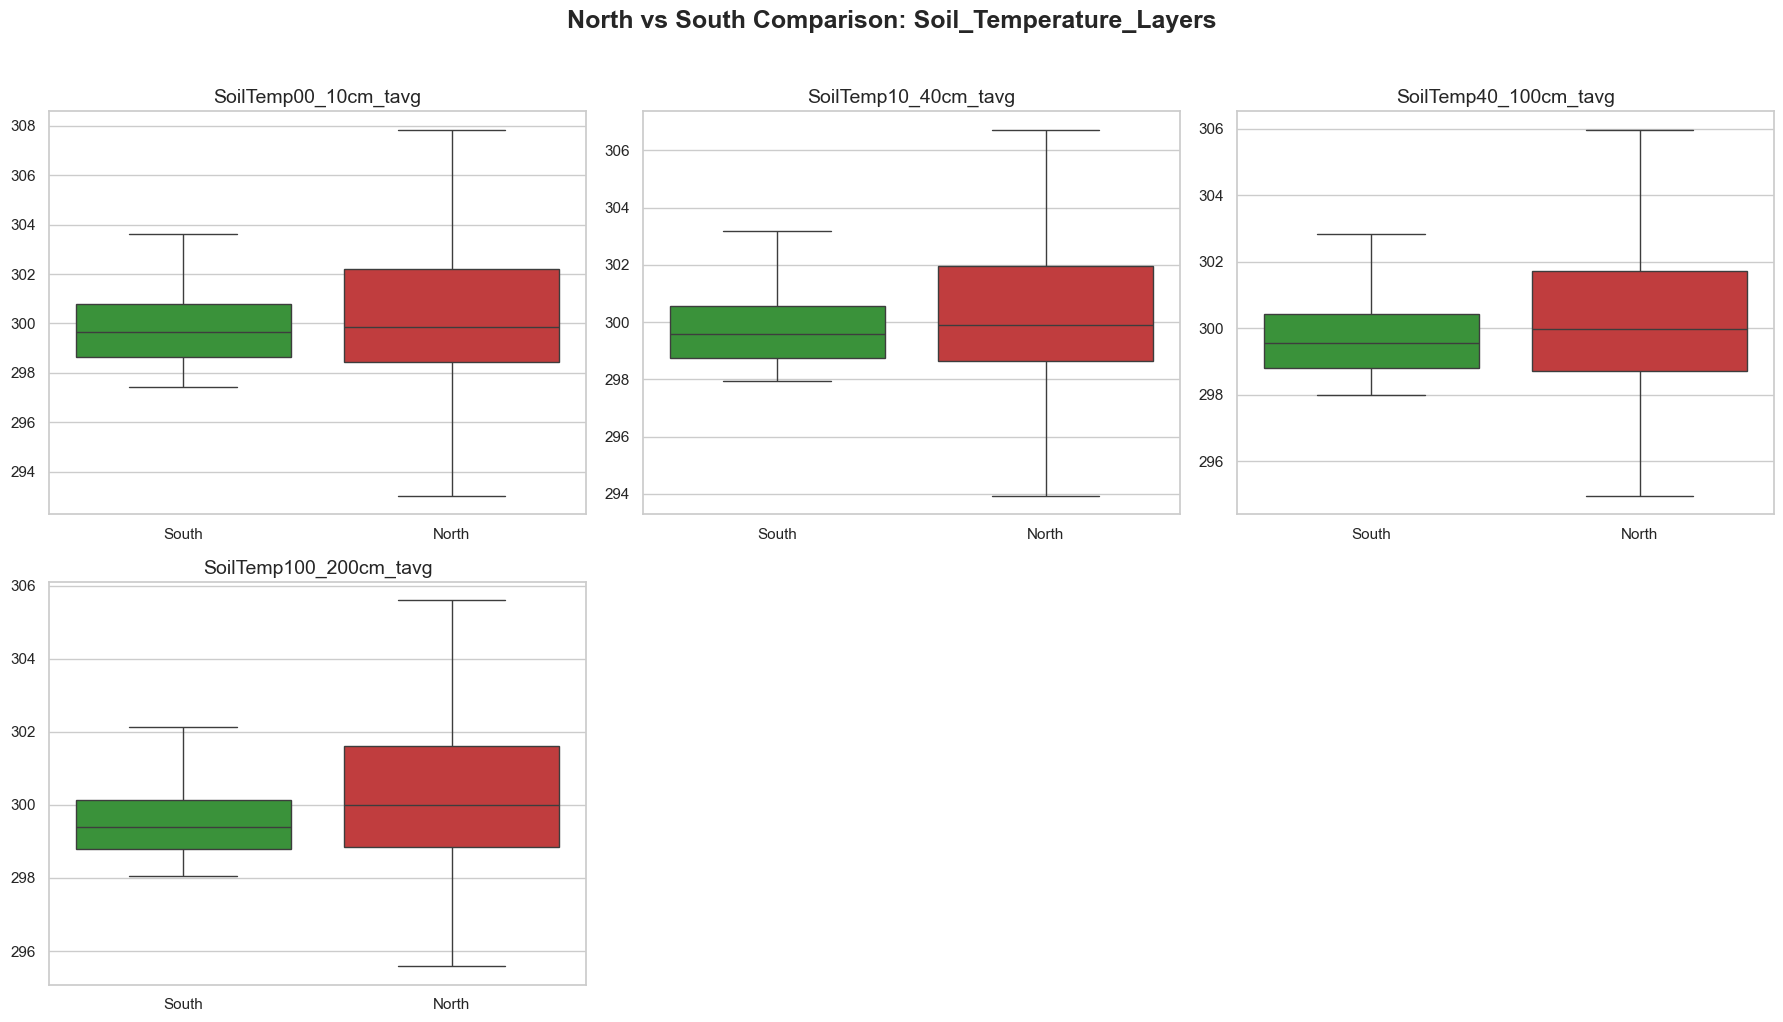

C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

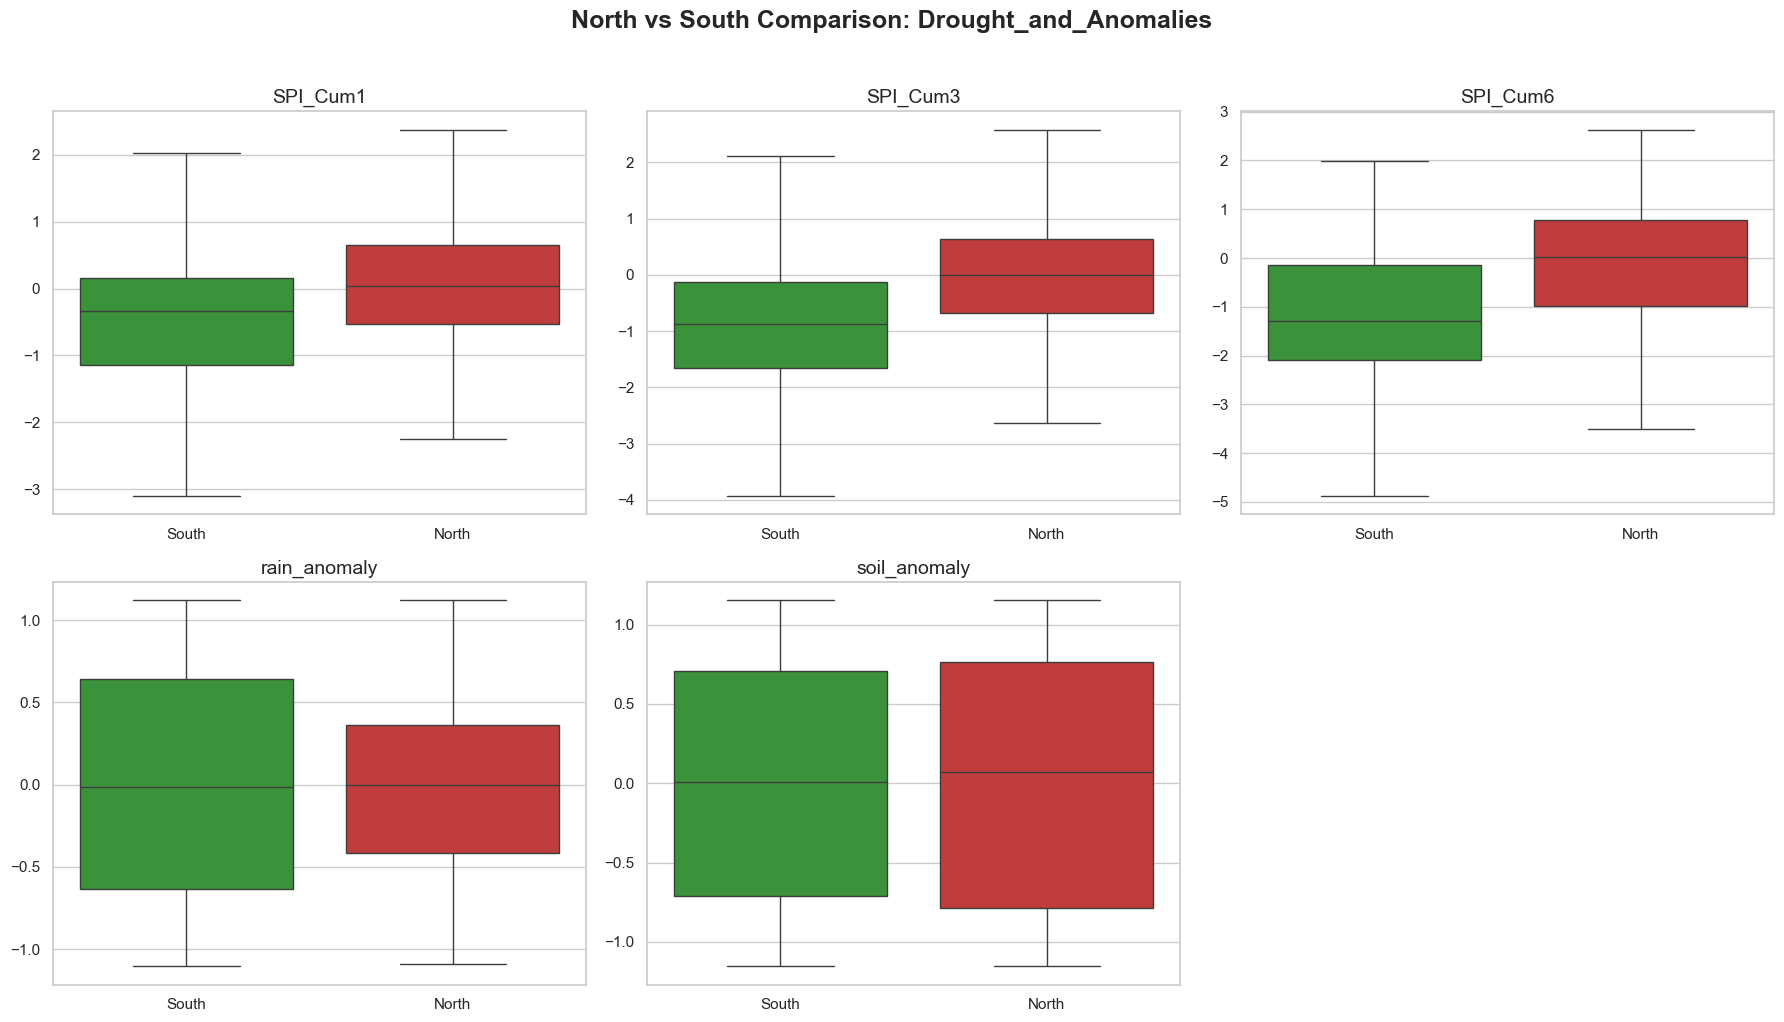

C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_20792\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

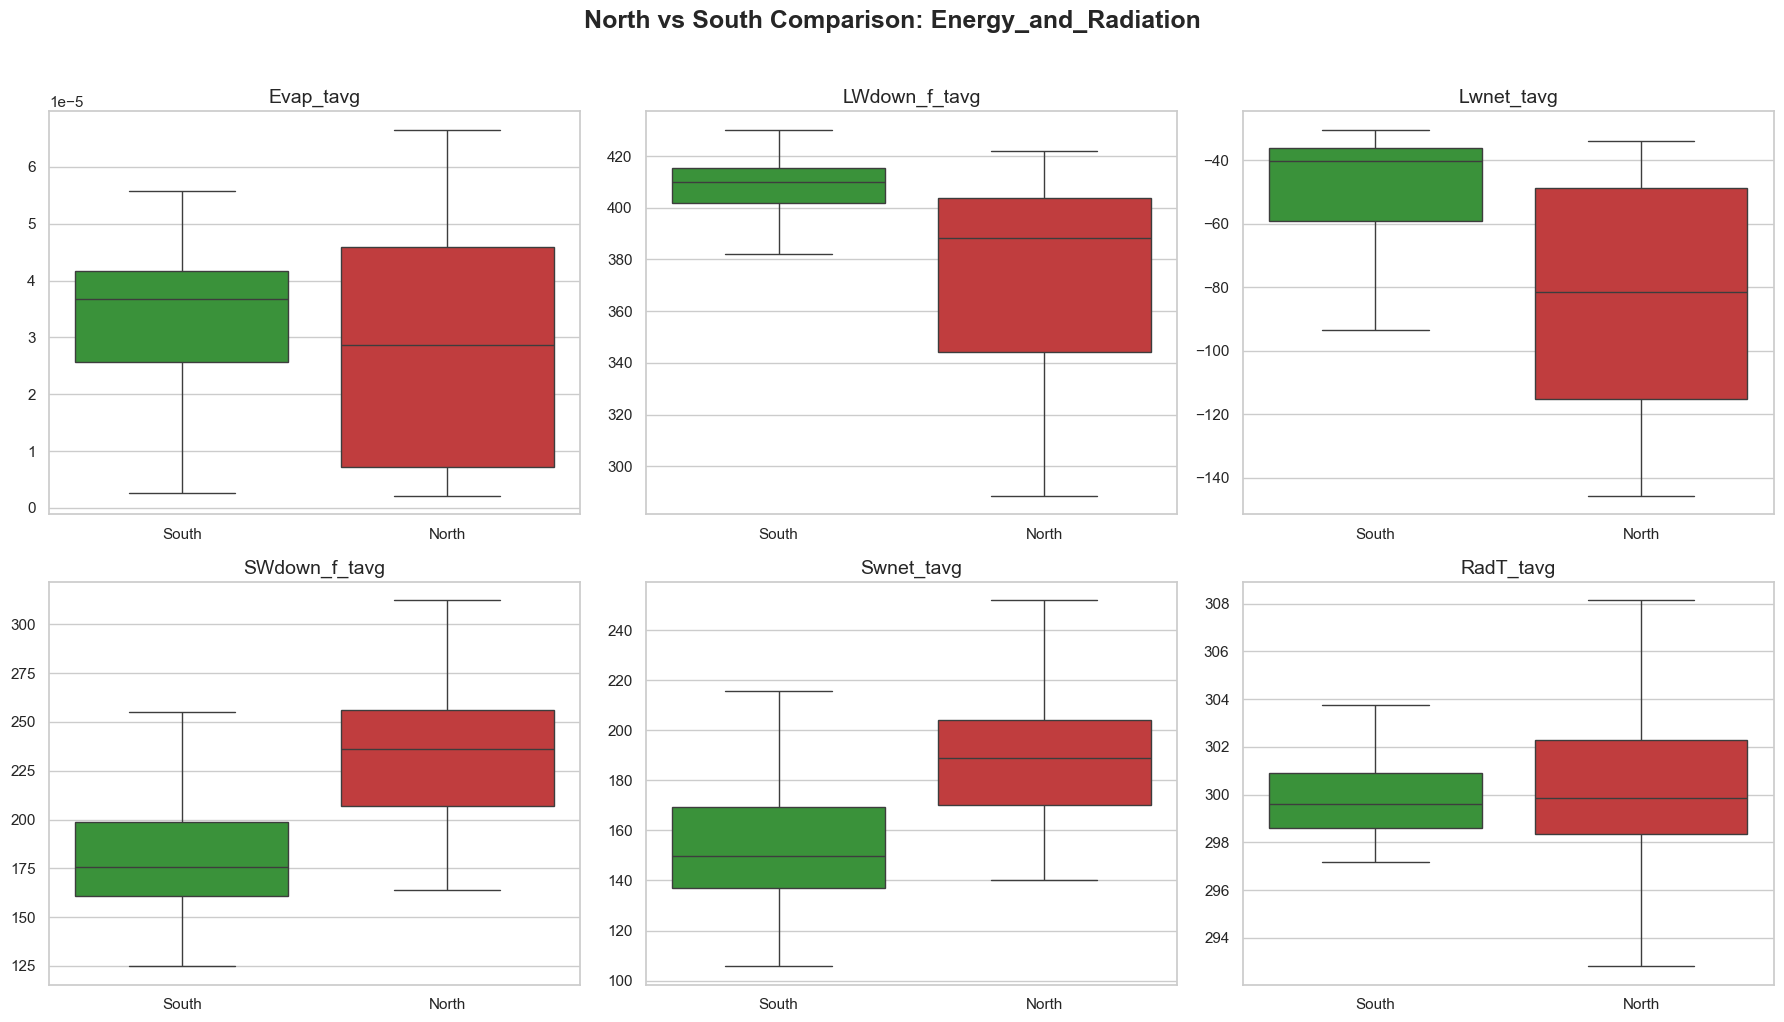

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# 1. Define logical groups of variables for the analysis
# This avoids plotting metadata or coordinates and groups related features
variable_groups = {
    "Target_and_Main_Indices": ['inadequate', 'WSI', 'FPAR_Zscore', 'ndvi_anomaly', 'vim', 'viq'],
    "Climate_Variables": ['Rainf_f_tavg', 'Tair_f_tavg', 'Wind_f_tavg', 'Psurf_f_tavg', 'Qair_f_tavg'],
    "Soil_Moisture_Layers": ['SoilMoi00_10cm_tavg', 'SoilMoi10_40cm_tavg', 'SoilMoi40_100cm_tavg', 'SoilMoi100_200cm_tavg'],
    "Soil_Temperature_Layers": ['SoilTemp00_10cm_tavg', 'SoilTemp10_40cm_tavg', 'SoilTemp40_100cm_tavg', 'SoilTemp100_200cm_tavg'],
    "Drought_and_Anomalies": ['SPI_Cum1', 'SPI_Cum3', 'SPI_Cum6', 'rain_anomaly', 'soil_anomaly'],
    "Energy_and_Radiation": ['Evap_tavg', 'LWdown_f_tavg', 'Lwnet_tavg', 'SWdown_f_tavg', 'Swnet_tavg', 'RadT_tavg']
}

# 2. General plotting function
def plot_grouped_boxplots(df, groups):
    sns.set_theme(style="whitegrid")
    
    for group_name, vars in groups.items():
        # Filter available columns to avoid errors
        available_vars = [v for v in vars if v in df.columns]
        if not available_vars:
            continue
            
        num_vars = len(available_vars)
        cols = 3
        rows = math.ceil(num_vars / cols)
        
        fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
        fig.suptitle(f'North vs South Comparison: {group_name}', fontsize=18, fontweight='bold', y=1.02)
        
        axes = axes.flatten()
        
        for i, var in enumerate(available_vars):
            sns.boxplot(
                data=df, 
                x='geopolitical_region', 
                y=var, 
                ax=axes[i], 
                palette={'North': 'tab:red', 'South': 'tab:green'},
                order=['South', 'North'],
                showfliers=False # Hidden for better clarity of distributions
            )
            axes[i].set_title(f'{var}', fontsize=14)
            axes[i].set_xlabel('')
            axes[i].set_ylabel('')
            
        # Hide any unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
            
        plt.tight_layout()
        plt.show()

# 3. Execution
plot_grouped_boxplots(df, variable_groups)

# Correlations

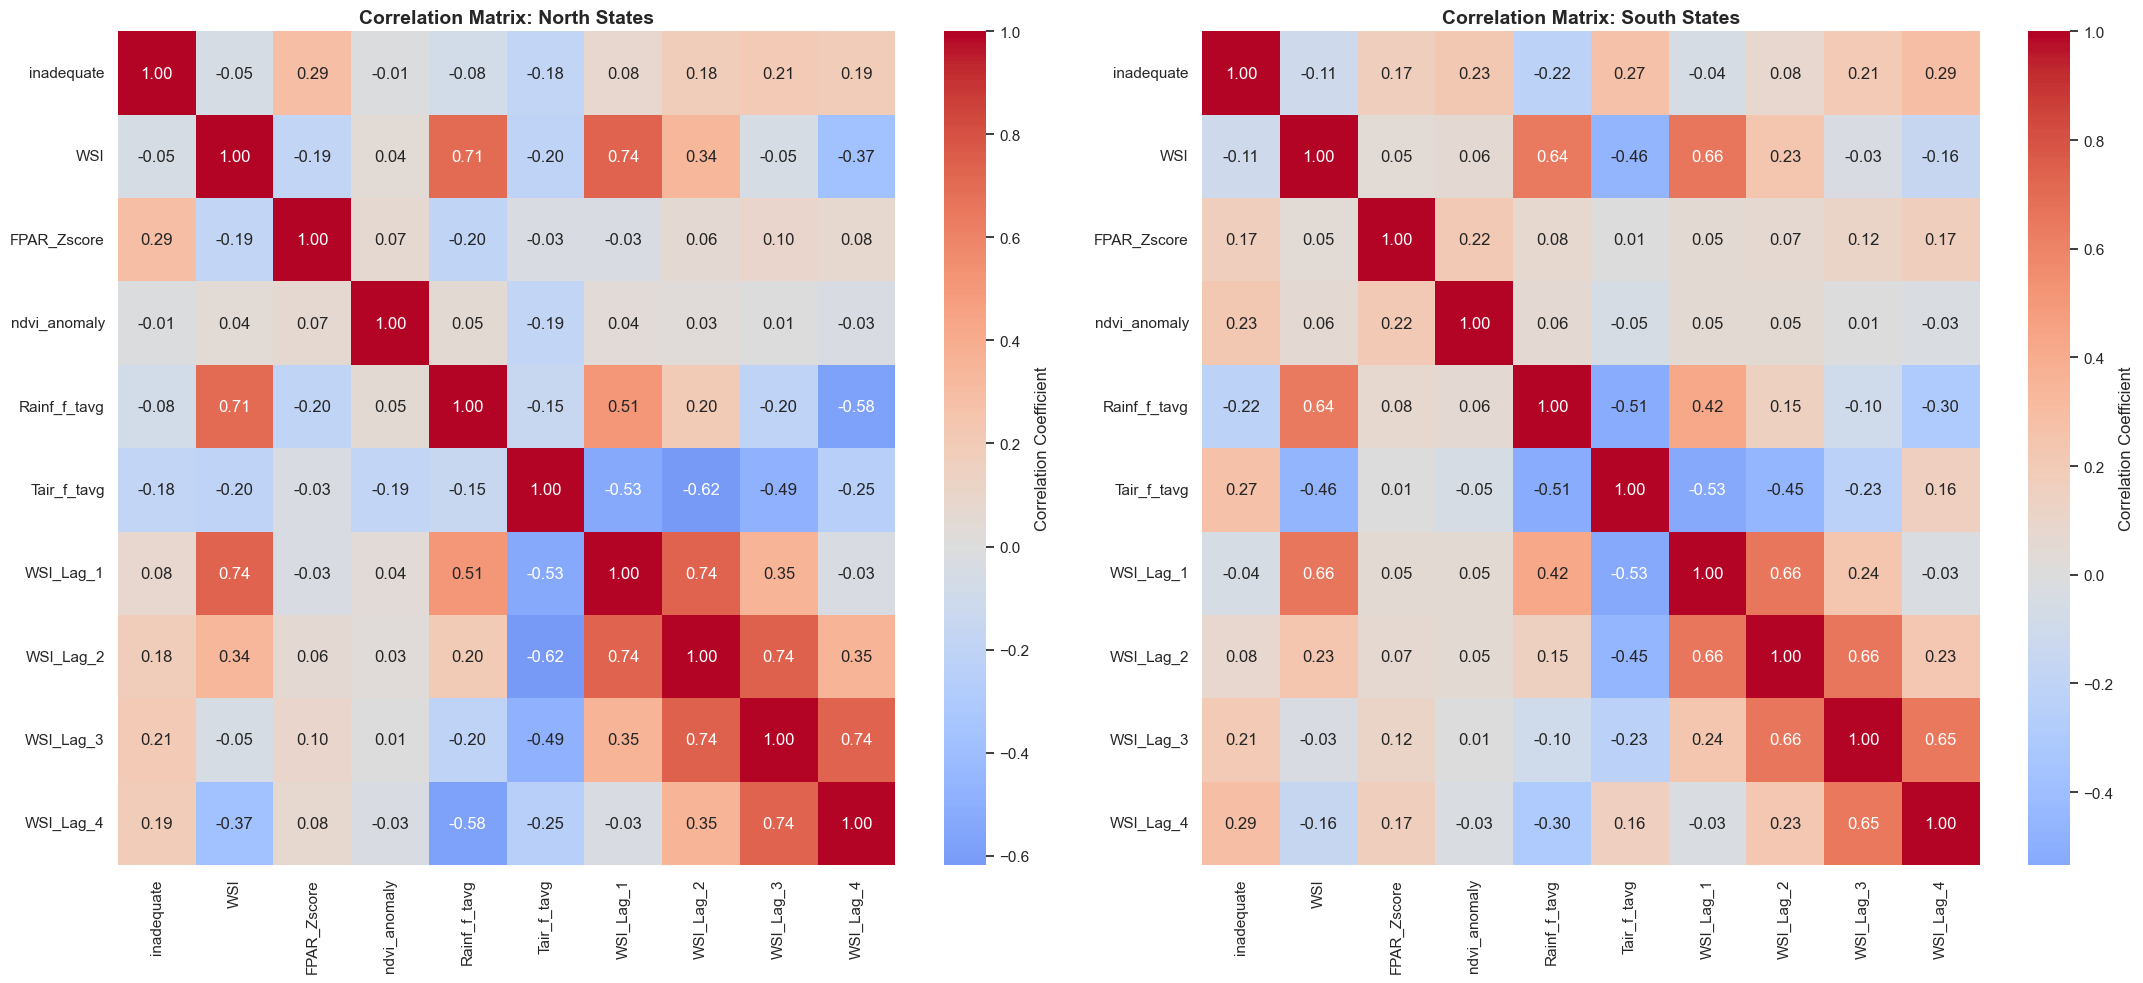

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selection of key variables for the correlation study
# We include the target variable, main climate drivers, and WSI lags
cols_to_study = [
    'inadequate', 'WSI', 'FPAR_Zscore', 'ndvi_anomaly', 
    'Rainf_f_tavg', 'Tair_f_tavg',
    'WSI_Lag_1', 'WSI_Lag_2', 'WSI_Lag_3', 'WSI_Lag_4'
]

# Filtering to keep only the columns actually present in the dataframe
cols_to_study = [col for col in cols_to_study if col in df.columns]

# 2. Function to plot a clean correlation heatmap
def plot_regional_heatmap(df, region_name, ax):
    # Filter data for the specific region
    # We use 'geopolitical_region' column created in the previous steps
    region_data = df[df['geopolitical_region'] == region_name]
    
    if region_data.empty:
        print(f"Warning: No data available for region: {region_name}")
        return

    # Calculate Pearson correlation
    region_corr = region_data[cols_to_study].corr()
    
    # Plotting the heatmap 
    # FIXED: Changed 'cbar_kds' to 'cbar_kws'
    sns.heatmap(region_corr, 
                annot=True, 
                cmap='coolwarm', 
                fmt=".2f", 
                center=0, 
                ax=ax, 
                cbar_kws={'label': 'Correlation Coefficient'})
    
    ax.set_title(f'Correlation Matrix: {region_name} States', fontsize=14, fontweight='bold')

# 3. Execution on a double-panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

plot_regional_heatmap(df, 'North', ax1)
plot_regional_heatmap(df, 'South', ax2)

plt.tight_layout()
plt.show()

### 3. Correlation and Temporal Lag Analysis

The core of this analysis identifies the "Chain of Causality" between environmental shocks and nutritional outcomes. By comparing the North and South macro-regions, we observe distinct structural behaviors in how climate impacts food security.

#### 3.1. The Vegetation Signal (FPAR)
* **North (Correlation: 0.29)**: In the Northern states, the correlation between `inadequate` food consumption and the `FPAR_Zscore` is significantly more pronounced. This confirms that vegetation availability is a **direct driver** of food security in Sahelian zones, where local agricultural productivity is the primary source of food.
* **South (Correlation: 0.17)**: This link is notably weaker in the South. This supports the hypothesis that Southern food security is less dependent on local biomass and more influenced by **market dynamics, infrastructure, and price fluctuations** rather than immediate local production.

#### 3.2. Hydrological Lag Dynamics (WSI)
We analyzed the Water Stress Index (WSI) over multiple temporal offsets (t-1 to t-6) to identify the optimal impact window.
* **North (Optimal Lag: 3 Months)**: The correlation with water stress peaks at **3 months** ($r = 0.21$). This represents the "depletion window"—the time required for a failed harvest due to water scarcity to translate into exhausted household stocks.
* **South (Optimal Lag: 4 Months)**: Interestingly, the peak occurs later at **4 months** ($r = 0.29$). This suggests a different transmission mechanism, potentially reflecting the time required for supply disruptions or price shocks to propagate from Northern producing zones to Southern consumer markets.

#### 3.3. Key Methodological Takeaway
These results prove that food insecurity in Nigeria is not a static phenomenon but a **dynamic temporal process**. 
> "Our analysis moves beyond simultaneous variables to demonstrate a specific 3-to-4-month window between climatic anomalies and nutritional peaks. This finding is critical for early warning systems, as it defines the precise lead time available for humanitarian intervention before a climate shock manifests as a consumption crisis."